In [37]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("../src")
from utils import create_theme_and_change_plot_params

CUST_SEGM_PATH = Path("../data/processed/customer_segmentation.parquet")
df = pd.read_parquet(CUST_SEGM_PATH)

In [38]:
# look at the df
df.head()

,Customer ID,Frequency,Monetary,AvgQuantityPerLine,TotalItems,UniqueProducts,Recency,AvgOrderValue,ItemsPerOrder,Country
0,12346,11,372.859985,2.121212,70,26,164,33.896362,6.363636,United Kingdom
1,12347,2,1323.320068,11.661972,828,70,2,661.660034,414.000000,Iceland
2,12348,1,222.160019,18.650000,373,20,73,222.160019,373.000000,Finland
3,12349,3,2671.139893,9.735294,993,90,42,890.379964,331.000000,Italy
4,12351,1,300.929993,12.428571,261,21,10,300.929993,261.000000,Unspecified


In [39]:
# select features
features = ["Recency", "Frequency", "Monetary", "AvgOrderValue", "UniqueProducts", "ItemsPerOrder"]
X = df[features]

In [40]:
# check skewness (retail data is usually heavily skewed)
X.skew().sort_values(ascending=False)

ItemsPerOrder     46.464096
Monetary          24.000183
AvgOrderValue     11.281363
Frequency         10.546821
UniqueProducts     6.150791
Recency            1.282928
dtype: float64

In [41]:
# log-transform skewed variables
X = X.copy()

X["Monetary"] = np.log1p(X["Monetary"])
X["AvgOrderValue"] = np.log1p(X["AvgOrderValue"])
X["ItemsPerOrder"] = np.log1p(X["ItemsPerOrder"])

In [42]:
# scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

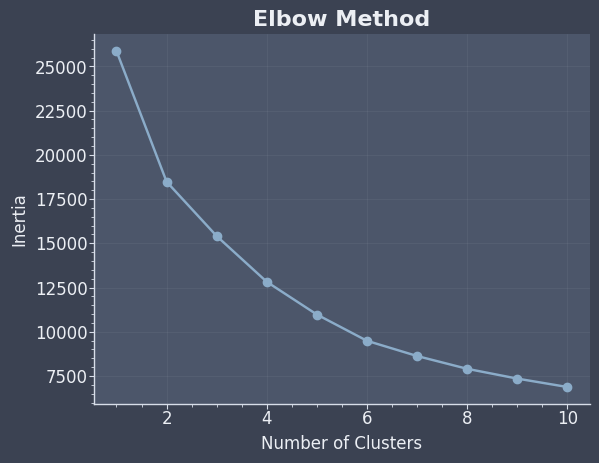

In [43]:
# find number of clusters (Elbow method)
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k,
                    random_state=42,
                    n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# create theme and matplotlib params
create_theme_and_change_plot_params()

# plot
plt.plot(range(1, 11), inertia, marker="o", color="#8bacc9")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

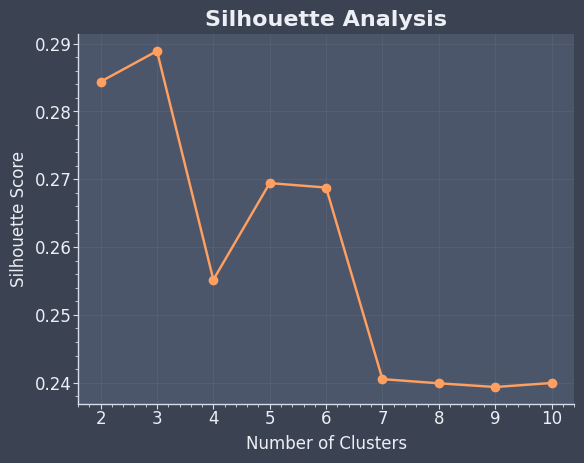

In [44]:
# silhouette score
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(
        X_scaled,
        labels
    )
    scores.append(score)
    
# plot
plt.plot(range(2, 11), scores, marker="o", color="#ff9f60")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

In [45]:
# choose 3 for the best number of clusters
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [46]:
# explore clusters
cluster_summary = (df.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    Recency=("Recency", "mean"),
    AvgOrderValue=("AvgOrderValue", "mean"),
    UniqueProducts=("UniqueProducts", "mean")
).round(2))

# look at the summary
cluster_summary

,Customers,Frequency,Monetary,Recency,AvgOrderValue,UniqueProducts
Cluster,,,,,,
0,2112,1.95,362.480011,132.21,201.76,25.28
1,2182,6.13,2972.840088,50.14,540.77,95.75
2,18,95.83,85885.343750,10.61,935.78,674.11


In [47]:
# visualize clusters with PCA
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# store results
df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

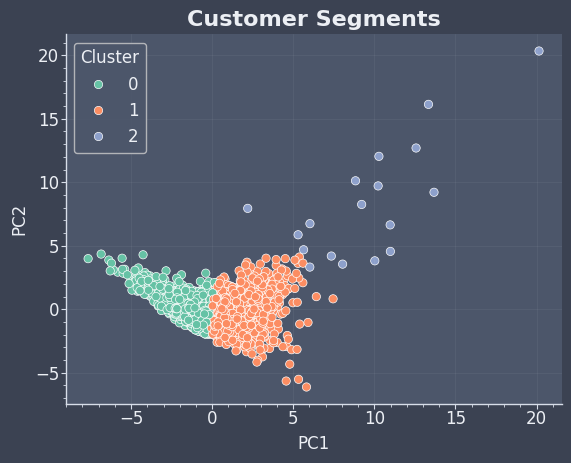

In [48]:
# plot
sns.scatterplot(data=df, x="PC1", y="PC2", hue="Cluster", palette="Set2")
plt.title("Customer Segments")
plt.show()

In [49]:
# calculate how much total revenue each segment contributes
cluster_summary["RevenueShare%"] = (
    df.groupby("Cluster").Monetary.sum() / df.Monetary.sum() * 100
).round(2)

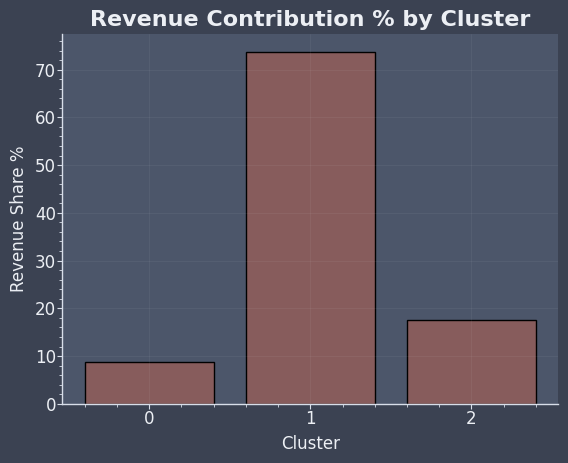

In [50]:
# check revenue share %
cluster_summary["RevenueShare%"]

# plot it
plt.bar(cluster_summary.index, cluster_summary["RevenueShare%"].values, edgecolor="black", color="#875c5c")
plt.xticks([0, 1, 2])
plt.xlabel("Cluster")
plt.ylabel("Revenue Share %")
plt.title("Revenue Contribution % by Cluster")
plt.show()

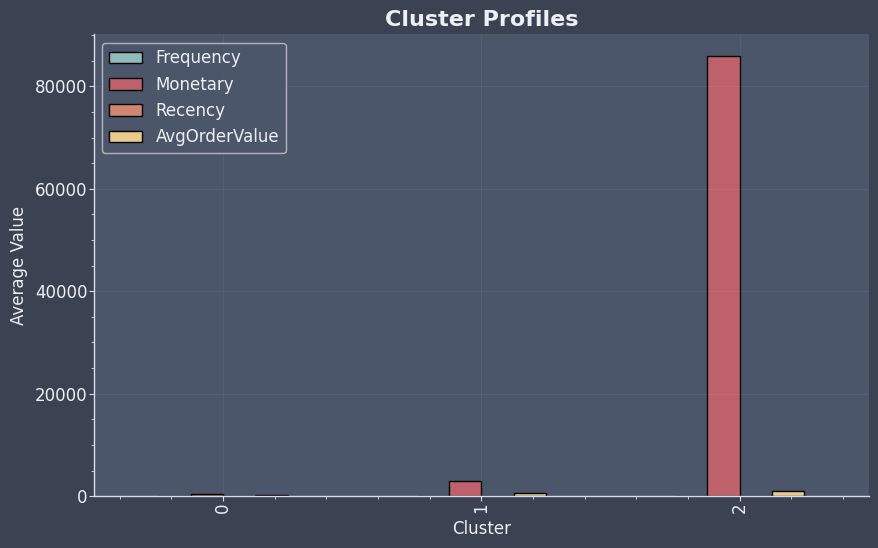

In [ ]:
# cluster profiling visualization
cluster_profile = df.groupby("Cluster").agg(
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    Recency=("Recency", "mean"),
    AvgOrderValue=("AvgOrderValue", "mean")
)

cluster_profile.plot(kind="bar", figsize=(10, 6), edgecolor="black")
plt.title("Cluster Profiles")
plt.ylabel("Average Value")
plt.show()

In [52]:
# save the final dataframe
df.to_parquet("../data/processed/customer_segmentation_clusters.parquet", index=False)

# K-Mean Clustering Conclusions

A K-Means clustering model was trained to identify distinct customer segments. The optimal number of clusters was determined to be three, as suggested by the Elbow Method and supported by the highest Silhouette Score (≈ 0.29), indicating moderate cluster separation.
The model identified three customer groups:

•	Cluster 0 (2,112 customers): Low-frequency, low-spending customers with relatively high recency values, indicating that they have not purchased recently. These customers can be considered occasional or inactive customers.

•	Cluster 1 (2,182 customers): The core customer base. Customers in this segment purchase more frequently, spend substantially more money and account for approximately 73.73% of total revenue.

•	Cluster 2 (18 customers): A small group of high-value customers. On average, they purchase 15.6 times more frequently than customers in Cluster 1. Although they represent less than 1% of all customers, they account for approximately 17.57% of total revenue, suggesting the presence of VIP, wholesale, or business customers.

Overall, the clustering analysis reveals that customer behavior is highly heterogeneous. While most customers belong to either occasional or regular buyer segments, a very small group of high-value customers contributes disproportionately to revenue and may warrant dedicated retention strategies.

# Business Recommendations

### Cluster 0: Inactive Customers

- Re-engagement campaigns
- Coupon incentives
- Email marketing

### Cluster 1: Core Customers

- Loyalty programs
- Product recommendations
- Upselling opportunities

### Cluster 2: VIP Customers

- Premium support
- Exclusive offers
- Retention-first strategy